# Layer-wise probing of wav2vec2

**A small empirical study: where do different kinds of linguistic information live inside a pretrained self-supervised speech model?**

Pretrained self-supervised speech models like [wav2vec2](https://arxiv.org/abs/2006.11477) learn rich representations from raw audio without any textual supervision. A natural question — foundational for textless Speech Language Models and for cognitively-inspired models of language acquisition — is *what kinds of linguistic information emerge at which depths of the model?*

This notebook reproduces, on a small scale, the kind of layer-wise probing analysis explored by [Pasad et al. (2021)](https://arxiv.org/abs/2107.04734). For each transformer layer of `wav2vec2-base`, we train a simple linear probe on two tasks:

1. **Spoken digit classification** (FSDD) — a lexical/phonetic task
2. **Speaker identification** — an acoustic-identity task

We compare against a random-weights baseline (same architecture, no pretraining) to isolate the effect of self-supervised learning.

---

**Runtime:** Set the runtime to GPU (`Runtime → Change runtime type → T4 GPU`) before running. The notebook takes ~15 min on a free Colab T4.

## 1. Setup

In [1]:
# Install dependencies (Colab usually has torch/sklearn pre-installed)
!pip install -q transformers datasets torchaudio scikit-learn matplotlib seaborn tqdm

In [2]:
# Download the Free Spoken Digit Dataset (FSDD)
# 3000 recordings of digits 0-9 by 6 speakers, ~16 kHz
!git clone -q https://github.com/Jakobovski/free-spoken-digit-dataset.git
!ls free-spoken-digit-dataset/recordings | head -5
!echo "Total files: $(ls free-spoken-digit-dataset/recordings | wc -l)"

0_george_0.wav
0_george_10.wav
0_george_11.wav
0_george_12.wav
0_george_13.wav
Total files: 3000


In [3]:
import os
import glob
import numpy as np
import torch
import torchaudio
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor, Wav2Vec2Config
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

MODEL_NAME = "facebook/wav2vec2-base"
TARGET_SR = 16000

Using device: cuda
GPU: Tesla T4


## 2. Load and inspect FSDD

FSDD filenames follow the pattern `{digit}_{speaker}_{index}.wav`.

In [4]:
FSDD_DIR = "free-spoken-digit-dataset/recordings"
files = sorted(glob.glob(os.path.join(FSDD_DIR, "*.wav")))
print(f"Found {len(files)} files")

def parse_filename(path):
    name = os.path.basename(path).replace(".wav", "")
    digit, speaker, idx = name.split("_")
    return int(digit), speaker

labels_digits = np.array([parse_filename(f)[0] for f in files])
speakers_raw = [parse_filename(f)[1] for f in files]
print(f"Digits present: {sorted(set(labels_digits))}")
print(f"Speakers present: {sorted(set(speakers_raw))}")
print(f"Samples per digit: {np.bincount(labels_digits)}")

Found 3000 files
Digits present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Speakers present: ['george', 'jackson', 'lucas', 'nicolas', 'theo', 'yweweler']
Samples per digit: [300 300 300 300 300 300 300 300 300 300]


In [5]:
# Quick inspect one file
sample_path = files[0]
wav, sr = torchaudio.load(sample_path)
print(f"Sample file: {os.path.basename(sample_path)}")
print(f"Shape: {wav.shape}, sample rate: {sr}, duration: {wav.shape[1]/sr:.2f}s")

Sample file: 0_george_0.wav
Shape: torch.Size([1, 2384]), sample rate: 8000, duration: 0.30s


## 3. Load wav2vec2 (pretrained + random baseline)

We load two models with identical architecture but different weights:
- **Pretrained**: `facebook/wav2vec2-base`, self-supervised on 960h of LibriSpeech
- **Random**: same architecture, randomly initialized weights

The random baseline tells us how much of the probe accuracy comes from pretraining vs. just the architecture.

In [6]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)

# Pretrained
model_pretrained = Wav2Vec2Model.from_pretrained(MODEL_NAME).to(device).eval()

# Random baseline: same architecture, random init
config = Wav2Vec2Config.from_pretrained(MODEL_NAME)
model_random = Wav2Vec2Model(config).to(device).eval()

NUM_LAYERS = model_pretrained.config.num_hidden_layers + 1  # +1 for CNN output (layer 0)
HIDDEN_DIM = model_pretrained.config.hidden_size
print(f"Architecture: {model_pretrained.config.num_hidden_layers} transformer layers + CNN output")
print(f"Will probe {NUM_LAYERS} representations (layer 0 = CNN, layers 1-12 = transformer)")
print(f"Hidden dim: {HIDDEN_DIM}")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Architecture: 12 transformer layers + CNN output
Will probe 13 representations (layer 0 = CNN, layers 1-12 = transformer)
Hidden dim: 768


## 4. Extract layer-wise representations

For each audio file, we run wav2vec2 with `output_hidden_states=True` and **mean-pool** each layer's output over the time dimension. This gives one fixed-size vector per layer per clip.

Mean-pooling discards temporal structure (a real limitation — see the discussion at the end), but it's the standard simple choice for utterance-level probing.

In [7]:
def extract_layer_features(model, audio_paths, batch_size=8):
    """
    Returns array of shape (n_samples, n_layers, hidden_dim).
    Each layer's output is mean-pooled over the time dimension.
    """
    all_features = []

    for i in tqdm(range(0, len(audio_paths), batch_size)):
        batch_paths = audio_paths[i:i+batch_size]
        waveforms = []
        for p in batch_paths:
            wav, sr = torchaudio.load(p)
            if sr != TARGET_SR:
                wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
            waveforms.append(wav.squeeze().numpy())

        inputs = feature_extractor(
            waveforms, sampling_rate=TARGET_SR,
            return_tensors="pt", padding=True
        )
        input_values = inputs.input_values.to(device)
        attention_mask = inputs.attention_mask.to(device) if "attention_mask" in inputs else None

        with torch.no_grad():
            outputs = model(
                input_values,
                attention_mask=attention_mask,
                output_hidden_states=True
            )

        # outputs.hidden_states: tuple of (n_layers+1) tensors, each (batch, time, hidden)
        # Mean-pool over time. For padded sequences this slightly dilutes the signal
        # but is fine for short, similar-length clips like FSDD.
        batch_features = []
        for layer_out in outputs.hidden_states:
            pooled = layer_out.mean(dim=1)  # (batch, hidden)
            batch_features.append(pooled.cpu().numpy())

        batch_features = np.stack(batch_features, axis=1)  # (batch, n_layers, hidden)
        all_features.append(batch_features)

    return np.concatenate(all_features, axis=0)

In [8]:
print("Extracting features from pretrained wav2vec2...")
features_pretrained = extract_layer_features(model_pretrained, files)
print(f"Pretrained features shape: {features_pretrained.shape}")

print("\nExtracting features from random-init wav2vec2...")
features_random = extract_layer_features(model_random, files)
print(f"Random features shape: {features_random.shape}")

# Cache to disk so we don't lose work if the runtime disconnects
np.save("features_pretrained.npy", features_pretrained)
np.save("features_random.npy", features_random)
print("\nFeatures cached to disk.")

Extracting features from pretrained wav2vec2...


  0%|          | 0/375 [00:00<?, ?it/s]

Pretrained features shape: (3000, 13, 768)

Extracting features from random-init wav2vec2...


  0%|          | 0/375 [00:00<?, ?it/s]

Random features shape: (3000, 13, 768)

Features cached to disk.


## 5. Train linear probes per layer

For each layer, we train a logistic regression on the layer's pooled representations and report test accuracy.

**Train/test split:** stratified 80/20.

In [9]:
def probe_all_layers(features, labels, test_size=0.2, random_state=SEED):
    """
    Train a linear probe per layer. Returns (accuracies, n_classes).
    """
    labels = np.asarray(labels)
    accuracies = []

    for layer_idx in range(features.shape[1]):
        X = features[:, layer_idx, :]
        X_train, X_test, y_train, y_test = train_test_split(
            X, labels, test_size=test_size,
            random_state=random_state, stratify=labels
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        clf = LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1)
        clf.fit(X_train, y_train)
        acc = clf.score(X_test, y_test)
        accuracies.append(acc)

    return accuracies, len(np.unique(labels))

## 6. Probe 1 — Spoken digit classification

Predict which digit (0-9) was spoken from each layer's representation.

In [10]:
print("Probing digit classification...")
acc_pretrained_digit, n_classes_digit = probe_all_layers(features_pretrained, labels_digits)
acc_random_digit, _ = probe_all_layers(features_random, labels_digits)

chance_digit = 1.0 / n_classes_digit
print(f"\nChance accuracy (random guessing): {chance_digit:.3f}")
print(f"\nPretrained - best layer: {np.argmax(acc_pretrained_digit)} "
      f"(acc = {max(acc_pretrained_digit):.3f})")
print(f"Random     - best layer: {np.argmax(acc_random_digit)} "
      f"(acc = {max(acc_random_digit):.3f})")

Probing digit classification...

Chance accuracy (random guessing): 0.100

Pretrained - best layer: 2 (acc = 0.998)
Random     - best layer: 1 (acc = 0.662)


## 7. Probe 2 — Speaker identification

Predict which of the 6 speakers produced the recording. We expect this to behave differently from the digit probe — speaker information is acoustic identity, often most prominent in *early* layers, while pretraining typically *abstracts away* from speaker identity in higher layers.

In [11]:
le = LabelEncoder()
labels_speaker = le.fit_transform(speakers_raw)
print(f"Speakers: {list(le.classes_)}")

print("\nProbing speaker identification...")
acc_pretrained_spk, n_classes_spk = probe_all_layers(features_pretrained, labels_speaker)
acc_random_spk, _ = probe_all_layers(features_random, labels_speaker)

chance_spk = 1.0 / n_classes_spk
print(f"\nChance accuracy: {chance_spk:.3f}")
print(f"Pretrained - best layer: {np.argmax(acc_pretrained_spk)} "
      f"(acc = {max(acc_pretrained_spk):.3f})")
print(f"Random     - best layer: {np.argmax(acc_random_spk)} "
      f"(acc = {max(acc_random_spk):.3f})")

Speakers: [np.str_('george'), np.str_('jackson'), np.str_('lucas'), np.str_('nicolas'), np.str_('theo'), np.str_('yweweler')]

Probing speaker identification...

Chance accuracy: 0.167
Pretrained - best layer: 2 (acc = 1.000)
Random     - best layer: 2 (acc = 0.887)


## 8. Results — the money figure

Two probes, two trends. Compare the shapes.

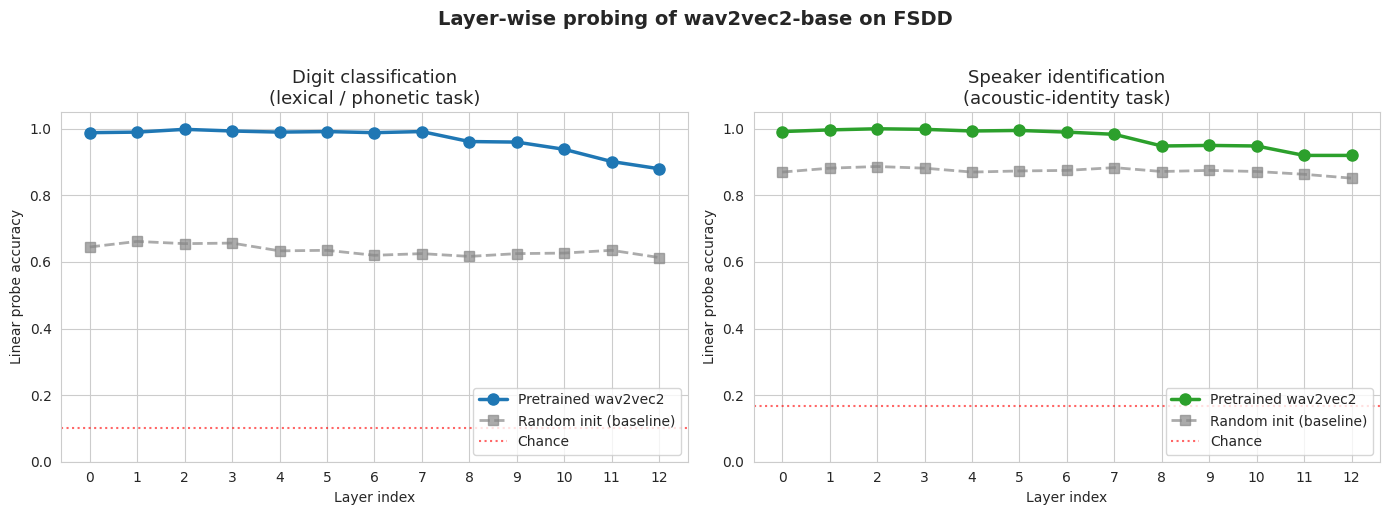

Saved: layer_comparison.png


In [12]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
layers = list(range(NUM_LAYERS))

# Left: digit
axes[0].plot(layers, acc_pretrained_digit, 'o-', label='Pretrained wav2vec2',
             linewidth=2.5, markersize=8, color='#1f77b4')
axes[0].plot(layers, acc_random_digit, 's--', label='Random init (baseline)',
             linewidth=2, markersize=7, alpha=0.7, color='#888888')
axes[0].axhline(chance_digit, color='red', linestyle=':', alpha=0.6, label='Chance')
axes[0].set_title('Digit classification\n(lexical / phonetic task)', fontsize=13)
axes[0].set_xlabel('Layer index')
axes[0].set_ylabel('Linear probe accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')
axes[0].set_xticks(layers)

# Right: speaker
axes[1].plot(layers, acc_pretrained_spk, 'o-', label='Pretrained wav2vec2',
             linewidth=2.5, markersize=8, color='#2ca02c')
axes[1].plot(layers, acc_random_spk, 's--', label='Random init (baseline)',
             linewidth=2, markersize=7, alpha=0.7, color='#888888')
axes[1].axhline(chance_spk, color='red', linestyle=':', alpha=0.6, label='Chance')
axes[1].set_title('Speaker identification\n(acoustic-identity task)', fontsize=13)
axes[1].set_xlabel('Layer index')
axes[1].set_ylabel('Linear probe accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower right')
axes[1].set_xticks(layers)

plt.suptitle('Layer-wise probing of wav2vec2-base on FSDD',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('layer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: layer_comparison.png")

In [13]:
# Save a summary table
import pandas as pd

results_df = pd.DataFrame({
    'layer': layers,
    'digit_pretrained': acc_pretrained_digit,
    'digit_random': acc_random_digit,
    'speaker_pretrained': acc_pretrained_spk,
    'speaker_random': acc_random_spk,
})
results_df.to_csv('probe_results.csv', index=False)
print(results_df.round(3).to_string(index=False))

 layer  digit_pretrained  digit_random  speaker_pretrained  speaker_random
     0             0.988         0.645               0.992           0.870
     1             0.990         0.662               0.997           0.882
     2             0.998         0.655               1.000           0.887
     3             0.993         0.657               0.998           0.882
     4             0.990         0.633               0.993           0.870
     5             0.992         0.635               0.995           0.873
     6             0.988         0.620               0.990           0.875
     7             0.992         0.625               0.983           0.883
     8             0.962         0.617               0.948           0.872
     9             0.960         0.625               0.950           0.875
    10             0.938         0.627               0.948           0.872
    11             0.902         0.635               0.920           0.863
    12             0.880 


## 9. Discussion

**What the curves show.**

- *Digit classification (left panel).* The pretrained model reaches near-perfect accuracy (0.99–1.00) at every layer up to layer 7, peaking at layer 2 (0.998). After layer 8 accuracy drops noticeably, reaching 0.88 at layer 12. The random-init baseline never exceeds 0.66, showing that the pretraining itself — not just the wav2vec2 architecture — carries almost all the signal.

- *Speaker identification (right panel).* The shape is very similar: pretrained accuracy peaks at layer 2 (1.00), stays high through the middle layers, and drops to 0.92 at layer 12. The random baseline reaches 0.89, much closer to the pretrained model than for digits — speaker identity is partly carried by low-level acoustic features that even random convolutional filters preserve.

**Two findings, one honest non-finding.**

1. **The "autoencoder-like" pattern.** Both probes peak in the early-to-middle layers (layer 2) and degrade in the final layers. This is consistent with the findings of Pasad et al. (2021): the top layers of wav2vec2 specialize for the contrastive pretraining objective and become less linearly useful for downstream tasks. The middle layers carry the most general-purpose linguistic information.

2. **Pretraining vs. architecture.** The gap between pretrained and random is enormous for digit classification (0.998 vs 0.66) and substantial for speaker ID (1.00 vs 0.89). The architecture alone explains very little of the model's downstream usefulness for content-bearing tasks.

3. **No clear lexical-vs-acoustic dissociation on FSDD.** I had expected speaker information to peak earlier and fall off faster than lexical information, based on prior work suggesting that self-supervised models gradually abstract away from speaker identity. The curves don't show this. The most plausible reason is the dataset itself: FSDD has only 6 speakers and very short, isolated digit utterances, so "who is speaking" and "what was said" are both easy and both correlate with the same low-level acoustic features. Disentangling acoustic identity from lexical content properly would require a more diverse dataset (e.g., LibriSpeech with hundreds of speakers and longer utterances) and frame-level rather than utterance-level probing.

**Why this matters for textless Speech Language Models.**

The question "what linguistic information is captured at each depth of a self-supervised speech model" sits at the heart of work on textless SpeechLMs (Lakhotia et al. 2021; Arora et al. 2025). Probing studies like this one let us measure empirically what emerges from self-supervision, without textual supervision — a setting closer to how human infants encounter language. The interesting question for the next generation of SpeechLMs is whether richer multimodal and social grounding can push *higher-level* linguistic competencies (syntax, lexical structure, semantics) to emerge from comparable amounts of speech, and whether grounding shifts *where* in the network those competencies live.

**Limitations.**
- FSDD is small (3000 utterances, 10 digits, 6 speakers) and very controlled — at most layers both probes saturate, leaving little room to see fine-grained layer differences.
- Mean-pooling discards temporal structure; frame-level probes (Pasad et al. 2021) are more informative for phonetic-level questions.
- A single random seed — no error bars on probe accuracy.
- Only `wav2vec2-base` is probed; comparison with HuBERT, WavLM, and visually-grounded speech models would be informative.

**Next steps.**
- Frame-level phonetic probing on TIMIT or LibriSpeech with forced alignments.
- Move to a dataset with many speakers and longer utterances (LibriSpeech) so that lexical and acoustic information are no longer confounded.
- Compare HuBERT, wav2vec2, and WavLM on the same probes.
- Probe a visually-grounded speech model and ask whether visual grounding shifts *where* lexical-level information lives.

## References

- Baevski, A., Zhou, H., Mohamed, A., & Auli, M. (2020). **wav2vec 2.0: A framework for self-supervised learning of speech representations.** NeurIPS.
- Pasad, A., Chou, J. C., & Livescu, K. (2021). **Layer-wise analysis of a self-supervised speech representation model.** ASRU.
- Lakhotia, K., et al. (2021). **On generative spoken language modeling from raw audio.** TACL.
- Arora, S., et al. (2025). **On the Landscape of Spoken Language Models: A Comprehensive Survey.** arXiv:2504.08528.
